Imports and setup

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from random import randint
from math import pi as PI
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


train_data = pd.read_csv("train.csv")

#import warnings
#warnings.filterwarnings('ignore')

<ipython-input-21-38e90e4f5b40>:16: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv("train.csv")


Visualisation

In [ ]:

# שלב 1: סינון נתונים מספריים
#features = train_data.select_dtypes(include=['float64', 'int64'])

# שלב 2: הסרה של עמודת מטרה אם קיימת
#features = features.drop(columns=['target'], errors='ignore')

# שלב 3: נרמול
#scaler = StandardScaler()
#scaled_features = scaler.fit_transform(features)

# שלב 4: PCA
#pca = PCA(n_components=2)
#principal_components = pca.fit_transform(scaled_features)

# שלב 5: ויזואליזציה
#plt.figure(figsize=(8,6))
#plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.6)
#plt.xlabel("Principal Component 1")
#plt.ylabel("Principal Component 2")
#plt.title("PCA of train_data")
#plt.grid(True)
#plt.show()



In [ ]:
#Histograms:
# for column in train_data.columns:
#   if column != "ID":
#     plt.figure(figsize=(8, 4))
#     if pd.api.types.is_numeric_dtype(train_data[column]):
#         plt.hist(train_data[column].dropna(), bins=20, edgecolor='black', color='skyblue')
#         plt.title(f"Histogram of {column}")
#         plt.xlabel(column)
#         plt.ylabel("Frequency")
#     else:
#         train_data[column].value_counts().plot(kind='bar', edgecolor='black', color='skyblue')
#         plt.title(f"Value Counts of {column}")
#         plt.xlabel(column)
#         plt.ylabel("Count")
#     plt.xticks(rotation=45, ha='right')
#     plt.tight_layout()
#     plt.show()

In [ ]:
#Unifind same meaning features into a list:
def unify_to_list(df, features_list, unified_feature_name):
  df[unified_feature_name] = df[features_list].values.tolist()
  df[unified_feature_name] = df[unified_feature_name].apply(lambda row: sorted(set(str(s) for s in row if pd.notna(s))))

unify_to_list(train_data, ["applicant_race_name_1", "applicant_race_name_2", "applicant_race_name_3"], "applicant_races")


Text(0, 0.5, 'Count')

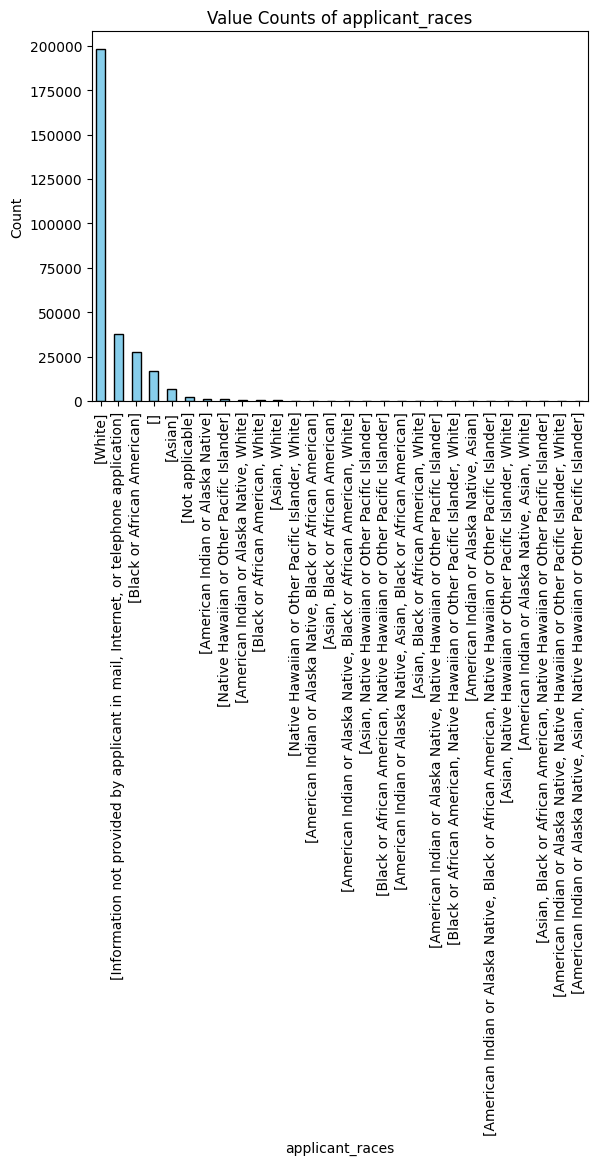

In [ ]:
train_data["applicant_races"].value_counts().plot(kind='bar', edgecolor='black', color='skyblue')
plt.title("Value Counts of applicant_races")
plt.xlabel("applicant_races")
plt.ylabel("Count")

# CORRELATION

In [ ]:
correlation = train_data['tract_to_msamd_income'].corr(train_data['applicant_income'])
print("Correlation:", correlation)

Correlation: 0.07858178611225232


In [ ]:
train_data.columns = train_data.columns.str.strip()

numeric_df = train_data.select_dtypes(include=['float64', 'int64'])

threshold = 0.6
for i, col1 in enumerate(numeric_df.columns):
    for j, col2 in enumerate(numeric_df.columns):
        if j > i:
            corr = numeric_df[col1].corr(numeric_df[col2])
            if abs(corr) > threshold:
                print(f"Correlation between '{col1}' and '{col2}': {corr:.3f}")


Correlation between 'population' and 'number_of_owner_occupied_units': 0.874
Correlation between 'population' and 'C': 0.878
Correlation between 'number_of_owner_occupied_units' and 'C': 0.949


After we found correlation - we want to see the vizualization

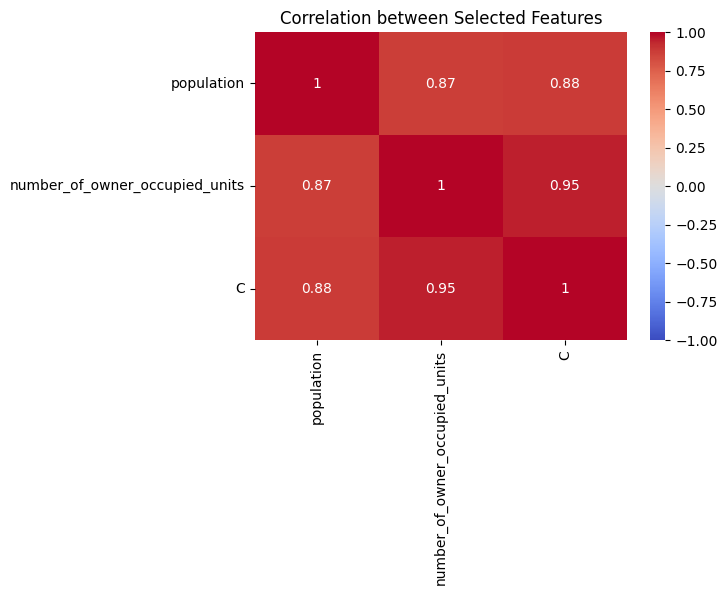

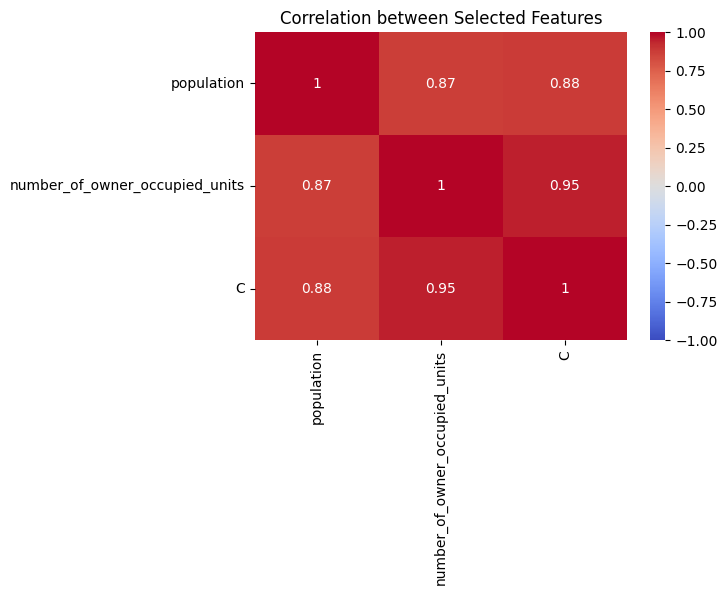

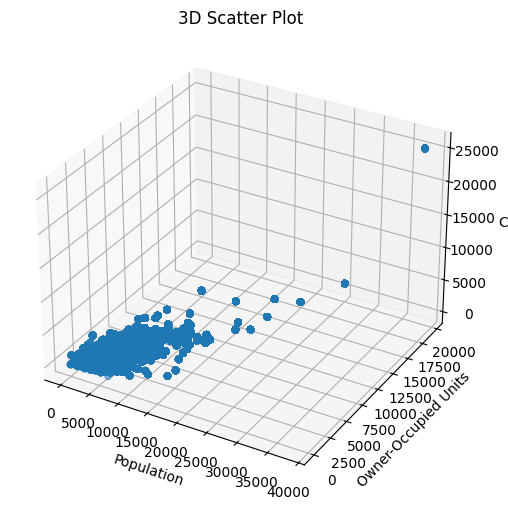

In [ ]:
cols = ['population', 'number_of_owner_occupied_units', 'C']
subset = train_data[cols]

subset.columns = subset.columns.str.strip()
corr_matrix = subset.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation between Selected Features")
plt.show()

cols = ['population', 'number_of_owner_occupied_units', 'C']
subset = train_data[cols]

subset.columns = subset.columns.str.strip()

corr_matrix = subset.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation between Selected Features")
plt.show()




fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    train_data['population'],
    train_data['number_of_owner_occupied_units'],
    train_data['C'],
    alpha=0.5
)

ax.set_xlabel("Population")
ax.set_ylabel("Owner-Occupied Units")
ax.set_zlabel("C")
plt.title("3D Scatter Plot")
plt.show()

